# 1ª Avaliação Prática – Caminho Mínimo com Dijkstra e Solução Gulosa

**Centro Federal de Educação Tecnológica de Minas Gerais**  
Modelagem Matemática Computacional  
Tópicos em Algoritmos em Grafos  
Prof. Thiago de Souza Rodrigues

---

## Objetivo
O trabalho tem como objetivo o teste e a comparação entre o algoritmo de Dijkstra e uma solução gulosa para obtenção do caminho mínimo em um grafo direcionado ponderado, considerando uma única origem e múltiplos destinos.

## Parte 1 — Dijkstra
  - I. Implementação do algoritmo de Dijkstra para caminho mínimo com origem única e múltiplos destinos.
  - II. Testes do algoritmo:
    - (a) Gerar grafos completos com 4, 5, 6, ..., N vértices, com pesos de arestas estritamente positivos (w > 0).
    - (b) Armazenar cada grafo em uma estrutura de dados escolhida (ex.: lista de adjacência).
    - (c) Aplicar o algoritmo do Item I considerando um vértice qualquer como origem (ex.: 0).
    - (d) Contar o número de comparações realizadas para cada grafo de entrada.
    - (e) Plotar gráfico com Eixo X = número de vértices (n) e Eixo Y = número de comparações.
    - Observação: limitar N a no máximo 1.000.000.
    - (f) Aplicar o algoritmo em duas instâncias (10.000 e 1.000.000 vértices), com origem no vértice 0, e mostrar o número de comparações em cada instância.

## Parte 2 — Heurística Gulosa
  - I. Implementação de uma heurística gulosa para caminho mínimo com origem única e múltiplos destinos.
  - II. Testes do algoritmo:
    - (a) Gerar grafos completos com 4, 5, 6, ..., N vértices, com pesos de arestas estritamente positivos (w > 0).
    - (b) Armazenar cada grafo na mesma estrutura de dados utilizada no Item I.
    - (c) Aplicar a heurística implementada considerando um vértice qualquer como origem (ex.: 0).
    - (d) Contar o número de comparações realizadas para cada grafo de entrada.
    - (e) Plotar gráfico com Eixo X = número de vértices (n) e Eixo Y = número de comparações.
    - Observação: limitar N a no máximo 1.000.000.
    - (f) Aplicar a heurística em duas instâncias (10.000 e 1.000.000 vértices), com origem no vértice 0, e mostrar o número de comparações em cada instância.

    ---

In [113]:
# Imports necessários
from typing import Dict, List, Tuple
from collections import deque
from math import inf
import heapq, random, os
import matplotlib.pyplot as plt
import numpy as np

---
# PARTE 1: ALGORITMO DE DIJKSTRA
---

## I. Implementação do Algoritmo de Dijkstra

In [114]:
def dijkstra(adj: Dict[int, List[Tuple[int, float]]], origem: int = 0):
    """
    Algoritmo de Dijkstra para caminho mínimo de origem única em GRAFO DIRIGIDO
    ponderado com pesos não negativos.

    Como funciona (resumo simples com heap binário):
    - Mantemos uma fila de prioridade (min-heap) com pares (distância acumulada, vértice).
    - Sempre processamos o vértice com MENOR distância conhecida primeiro.
    - Para cada aresta dirigida u->v com peso w, tentamos relaxar: se dist[u] + w < dist[v],
      atualizamos dist[v] e inserimos (dist[v], v) no heap.
    - Entradas antigas no heap são ignoradas quando saem (checando dist_u != dist[u]).

    Otimizações:
    - Usa listas internas para dist e parent (índices 0..n-1) para reduzir overhead de dict.
    - Mantém a API externa: retorna dicts (dist, parent) para compatibilidade com o notebook.
    - Pré-binda funções locais de heap para reduzir lookups dentro do loop.
    
    Retorna: (dist_dict, parent_dict, comparacoes)
    """
    # Tenta obter n assumindo vértices rotulados de 0..n-1 (padrão neste notebook)
    try:
        n = len(adj)
    except Exception:
        raise ValueError('Estrutura de grafo inválida: não possui len().')

    if n == 0 or not (0 <= origem < n):
        raise ValueError('Grafo vazio ou origem inválida')

    # Estruturas internas otimizadas (listas)
    dist = [inf] * n
    parent = [-1] * n
    dist[origem] = 0.0

    pq = [(0.0, origem)]
    comparacoes = 0

    # Pré-bind de funções/refs para micro-otimização em loop apertado
    heappop = heapq.heappop
    heappush = heapq.heappush
    dist_local = dist
    parent_local = parent
    adj_local = adj

    while pq:
        dist_u, u = heappop(pq)
        if dist_u != dist_local[u]:
            continue

        # Para grafos DIRIGIDOS: percorremos apenas as arestas de saída u->v
        for v, peso in adj_local[u]:
            comparacoes += 1
            nova_dist = dist_u + peso
            if nova_dist < dist_local[v]:
                dist_local[v] = nova_dist
                parent_local[v] = u
                heappush(pq, (nova_dist, v))

    # Converter de volta para dict para compatibilidade com o restante do notebook
    dist_dict = {u: dist_local[u] for u in range(n)}
    parent_dict = {u: (None if parent_local[u] == -1 else parent_local[u]) for u in range(n)}

    return dist_dict, parent_dict, comparacoes

## II. Teste do Algoritmo

### Configurações

In [115]:
# Parâmetros
N_MIN = 4
N_MAX = 1000         # ⚠️ REDUZIDO! Grafos completos crescem O(n²)
                    # Para n=100: 9.900 arestas por grafo
                    # Para testes maiores, use grafos ESPARSOS (10k/1M)
SEED = 42
ORIGEM = 0
# Escolher o grafo n=5 (índice 1, já que ns_teste começa em 4)
n_exemplo = 10

### (a) Gerar grafos completos com pesos > 0

In [116]:
def gerar_grafo_completo(n: int, peso_min: float = 1.0, peso_max: float = 10.0, seed: int = None):
    """
    Gera grafo completo dirigido com n vértices.
    
    OTIMIZAÇÕES:
    - Usa numpy para geração vetorizada de pesos (muito mais rápido)
    - Pré-aloca estruturas de dados
    - Evita append repetido (O(1) amortizado vs O(n) realocações)
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Gerar TODOS os pesos de uma vez (vetorizado, muito mais rápido!)
    num_arestas_total = n * (n - 1)
    pesos = np.random.uniform(peso_min, peso_max, size=num_arestas_total)
    
    # Construir grafo usando os pesos pré-gerados
    adj = {u: [] for u in range(n)}
    idx = 0
    
    for u in range(n):
        # Pré-alocar lista de vizinhos para este vértice
        vizinhos = []
        for v in range(n):
            if u != v:
                vizinhos.append((v, float(pesos[idx])))
                idx += 1
        adj[u] = vizinhos
    
    return adj

print(f"✓ Função de geração de grafos completos criada (OTIMIZADA)")
print(f"  Teste: grafo com 5 vértices tem {5*(5-1)} arestas esperadas")
print(f"  Otimizações:")
print(f"    - Geração vetorizada de pesos com NumPy (~10-100x mais rápido)")
print(f"    - Pré-alocação de estruturas")
print(f"    - Evita múltiplos appends (menos realocações de memória)")

✓ Função de geração de grafos completos criada (OTIMIZADA)
  Teste: grafo com 5 vértices tem 20 arestas esperadas
  Otimizações:
    - Geração vetorizada de pesos com NumPy (~10-100x mais rápido)
    - Pré-alocação de estruturas
    - Evita múltiplos appends (menos realocações de memória)


In [117]:
# ALTERNATIVA: Gerador LAZY para grafos muito grandes (não materializa todas as arestas)
class GrafoCompletoLazy:
    """
    Grafo completo DIRIGIDO que gera arestas u->v sob demanda (lazy).
    Usa ZERO memória para armazenar arestas - ideal para n > 1000.
    """
    def __init__(self, n: int, peso_min: float = 1.0, peso_max: float = 10.0, seed: int = None):
        self.n = n
        self.peso_min = peso_min
        self.peso_max = peso_max
        if seed is not None:
            self.rng = np.random.RandomState(seed)
        else:
            self.rng = np.random.RandomState()
    
    def __len__(self):
        return self.n
    
    def __iter__(self):
        return iter(range(self.n))
    
    def __getitem__(self, u):
        """Gera vizinhos de u sob demanda (arestas DIRIGIDAS u->v, não armazena na memória)."""
        # Gerar pesos para todos vizinhos de u de uma vez
        self.rng.seed(u * 1000)  # Seed determinístico por vértice
        pesos = self.rng.uniform(self.peso_min, self.peso_max, self.n - 1)
        
        vizinhos = []
        idx = 0
        for v in range(self.n):
            if v != u:
                vizinhos.append((v, float(pesos[idx])))
                idx += 1
        return vizinhos
    
    def keys(self):
        return range(self.n)

print("✓ Classe GrafoCompletoLazy criada (para n > 1000)")
print("  Vantagens:")
print("    - Memória O(1) em vez de O(n²)")
print("    - Gera arestas dirigidas apenas quando solicitado")
print("    - Ideal para Dijkstra/Gulosa que percorrem vértice a vértice")

✓ Classe GrafoCompletoLazy criada (para n > 1000)
  Vantagens:
    - Memória O(1) em vez de O(n²)
    - Gera arestas dirigidas apenas quando solicitado
    - Ideal para Dijkstra/Gulosa que percorrem vértice a vértice


### (b) Armazenar grafos em estrutura de dados

**Estrutura:** Lista de adjacência `{vértice: [(vizinho, peso), ...]}`

In [118]:
# Gerar grafos completos de teste
ns_teste = list(range(N_MIN, N_MAX + 1))

# Estratégia inteligente: usar versão lazy para n > 500
LIMITE_LAZY = 500

grafos_teste = []
for n in ns_teste:
    if n <= LIMITE_LAZY:
        # Versão otimizada (materializada) para grafos pequenos
        grafos_teste.append(gerar_grafo_completo(n, seed=SEED))
    else:
        # Versão lazy (sob demanda) para grafos grandes
        grafos_teste.append(GrafoCompletoLazy(n, seed=SEED))

print(f"✓ Gerados {len(grafos_teste)} grafos completos (n={N_MIN} até n={N_MAX})")


✓ Gerados 997 grafos completos (n=4 até n=1000)


### Exemplo de visualização de um grafo (n=5)

✓ Grafo de exemplo (n=10) plotado e salvo
  Arquivo: resultados/dijkstra/img/grafo_exemplo_n10.png


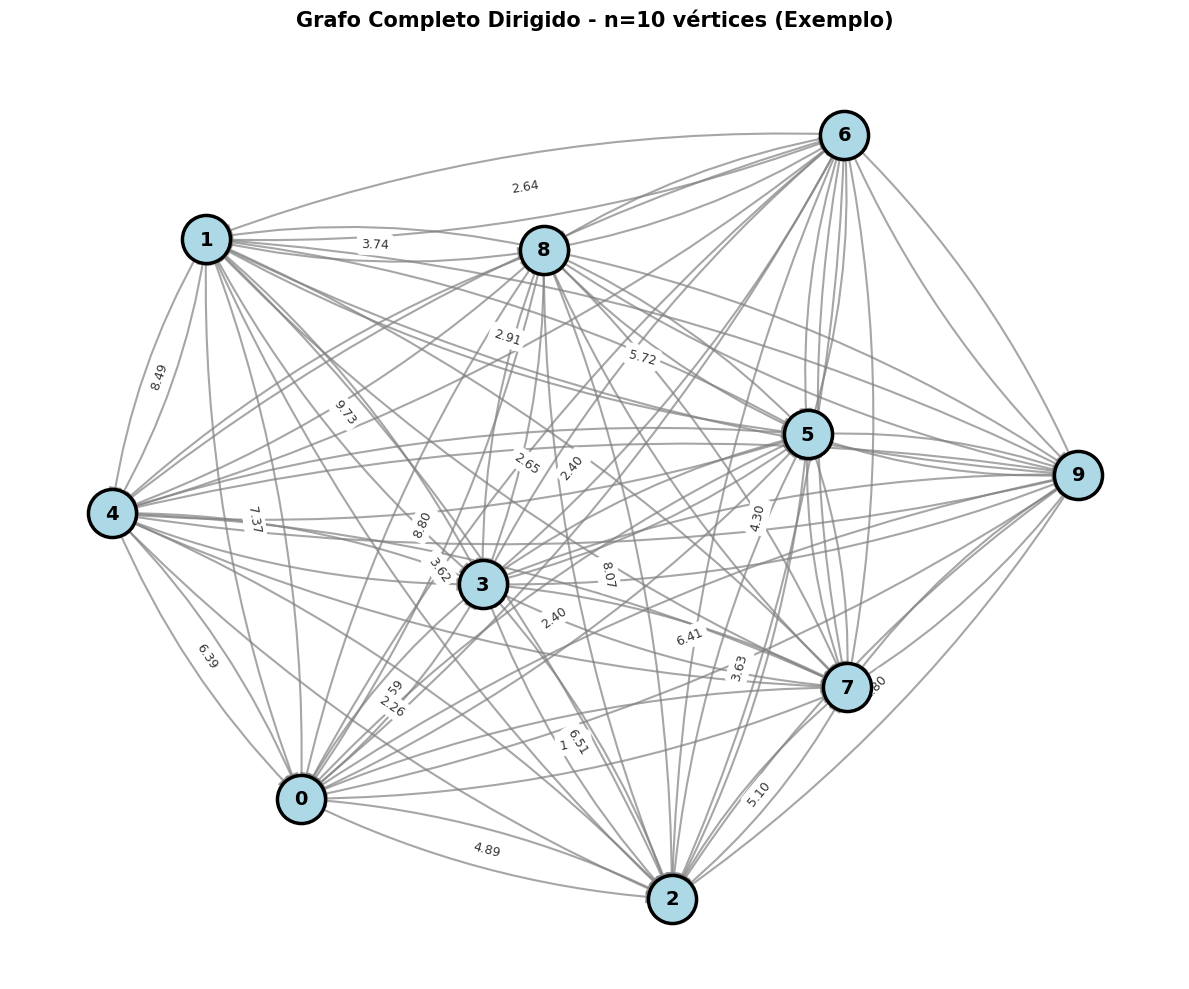

In [119]:
# Plotar apenas um grafo de exemplo (n=5) usando NetworkX
import networkx as nx


idx_exemplo = ns_teste.index(n_exemplo) if n_exemplo in ns_teste else 1
grafo_exemplo = grafos_teste[idx_exemplo]

# Criar grafo direcionado NetworkX
G = nx.DiGraph()
for u, vizinhos in grafo_exemplo.items():
    for v, peso in vizinhos:
        G.add_edge(u, v, weight=peso)

# Plotar
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=SEED, k=1.5, iterations=50)

# Desenhar nós
nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                      node_size=1200, edgecolors='black', linewidths=2.5)

# Desenhar arestas
nx.draw_networkx_edges(G, pos, edge_color='gray', 
                      arrows=True, arrowsize=20, width=1.5,
                      connectionstyle='arc3,rad=0.1', alpha=0.7)

# Labels dos nós
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

# Labels das arestas (pesos) - apenas alguns para não poluir
edge_labels = nx.get_edge_attributes(G, 'weight')
# Mostrar apenas arestas de vértices 0, 1, 2 para clareza
edge_labels_filtrado = {k: f'{v:.2f}' for k, v in edge_labels.items() if k[0] < 3}
nx.draw_networkx_edge_labels(G, pos, edge_labels_filtrado, font_size=9, alpha=0.8)

plt.title(f'Grafo Completo Dirigido - n={n_exemplo} vértices (Exemplo)', 
         fontsize=15, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()

# Salvar
os.makedirs('resultados/dijkstra/img', exist_ok=True)
plt.savefig(f'resultados/dijkstra/img/grafo_exemplo_n{n_exemplo}.png', dpi=200, bbox_inches='tight')
print(f'✓ Grafo de exemplo (n={n_exemplo}) plotado e salvo')
print(f'  Arquivo: resultados/dijkstra/img/grafo_exemplo_n{n_exemplo}.png')
plt.show()

### Exemplo de Grafo Esparso Simulado (n=10)

✓ Grafo esparso (DIRIGIDO) de exemplo (n=10) plotado e salvo
  Arquivo: resultados/dijkstra/img/grafo_esparso_exemplo_n10.png

📊 Características do Grafo Esparso (DIRIGIDO):
  Vértices: 10
  Arestas: 27/90
  Densidade: 30.0% (vs. 100% no grafo completo dirigido)
  Redução de arestas: 70.0%


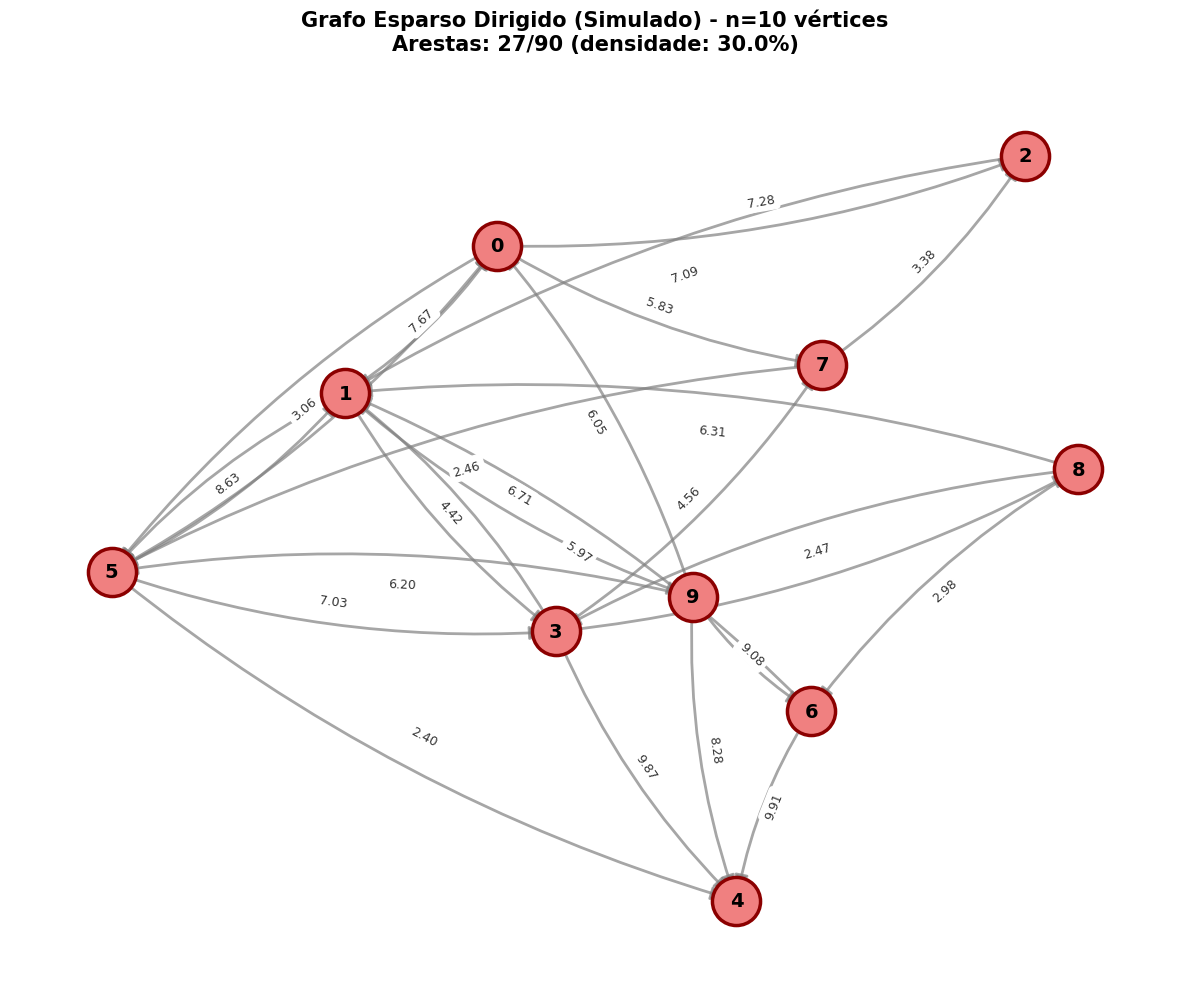

In [120]:
def gerar_grafo_esparso_simulado(n: int, densidade: float = 0.3, peso_min: float = 1.0, 
                                  peso_max: float = 10.0, seed: int = None):
    """
    Gera grafo esparso DIRIGIDO simulado com n vértices.
    
    Args:
        n: número de vértices
        densidade: proporção de arestas em relação ao grafo completo DIRIGIDO (0.0 a 1.0)
        peso_min, peso_max: intervalo de pesos
        seed: semente para reprodutibilidade
    
    Returns:
        adj: dicionário de adjacências (arestas u->v)
    """
    if seed is not None:
        random.seed(seed)
    
    adj = {u: [] for u in range(n)}
    max_arestas = n * (n - 1)  # Grafo completo DIRIGIDO
    num_arestas = int(max_arestas * densidade)
    
    arestas_adicionadas = 0
    tentativas = 0
    max_tentativas = num_arestas * 10
    
    while arestas_adicionadas < num_arestas and tentativas < max_tentativas:
        u = random.randint(0, n - 1)
        v = random.randint(0, n - 1)
        
        if u != v and not any(destino == v for destino, _ in adj[u]):
            peso = random.uniform(peso_min, peso_max)
            adj[u].append((v, peso))  # aresta DIRIGIDA u->v
            arestas_adicionadas += 1
        
        tentativas += 1
    
    return adj

# Gerar grafo esparso com 30% de densidade (usando n_exemplo definido anteriormente)
densidade_esparso = 0.3
grafo_esparso_exemplo = gerar_grafo_esparso_simulado(n_exemplo, densidade=densidade_esparso, seed=SEED)

# Criar grafo NetworkX
G_esparso = nx.DiGraph()
for u, vizinhos in grafo_esparso_exemplo.items():
    for v, peso in vizinhos:
        G_esparso.add_edge(u, v, weight=peso)

# Adicionar vértices isolados (se houver)
G_esparso.add_nodes_from(range(n_exemplo))

# Plotar
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_esparso, seed=SEED, k=1.2, iterations=50)

# Desenhar nós
nx.draw_networkx_nodes(G_esparso, pos, node_color='lightcoral', 
                      node_size=1200, edgecolors='darkred', linewidths=2.5)

# Desenhar arestas
nx.draw_networkx_edges(G_esparso, pos, edge_color='gray', 
                      arrows=True, arrowsize=20, width=2.0,
                      connectionstyle='arc3,rad=0.1', alpha=0.7)

# Labels dos nós
nx.draw_networkx_labels(G_esparso, pos, font_size=14, font_weight='bold')

# Labels das arestas (pesos)
edge_labels = nx.get_edge_attributes(G_esparso, 'weight')
edge_labels_formatado = {k: f'{v:.2f}' for k, v in edge_labels.items()}
nx.draw_networkx_edge_labels(G_esparso, pos, edge_labels_formatado, font_size=9, alpha=0.8)

# Informações do grafo
num_vertices = G_esparso.number_of_nodes()
num_arestas = G_esparso.number_of_edges()
max_arestas = n_exemplo * (n_exemplo - 1)
densidade_real = num_arestas / max_arestas if max_arestas > 0 else 0

plt.title(f'Grafo Esparso Dirigido (Simulado) - n={n_exemplo} vértices\n' + 
         f'Arestas: {num_arestas}/{max_arestas} (densidade: {densidade_real:.1%})', 
         fontsize=15, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()

# Salvar
plt.savefig(f'resultados/dijkstra/img/grafo_esparso_exemplo_n{n_exemplo}.png', dpi=200, bbox_inches='tight')
print(f'✓ Grafo esparso (DIRIGIDO) de exemplo (n={n_exemplo}) plotado e salvo')
print(f'  Arquivo: resultados/dijkstra/img/grafo_esparso_exemplo_n{n_exemplo}.png')
print(f'\n📊 Características do Grafo Esparso (DIRIGIDO):')
print(f'  Vértices: {num_vertices}')
print(f'  Arestas: {num_arestas}/{max_arestas}')
print(f'  Densidade: {densidade_real:.1%} (vs. 100% no grafo completo dirigido)')
print(f'  Redução de arestas: {(1 - densidade_real) * 100:.1f}%')
plt.show()

### Comparação Visual: Grafo Completo vs Grafo Esparso

✓ Comparação visual salva: resultados/dijkstra/img/comparacao_completo_vs_esparso.png

📊 COMPARAÇÃO:
  Tipo          │ Vértices │ Arestas │ Densidade │ Redução
----------------------------------------------------------------------
  Completo      │    10    │    90   │    100%  │    -
  Esparso       │    10    │    27   │     30%  │   70.0%

💡 Observação: Grafos esparsos têm MUITO menos arestas que grafos completos,
   o que reduz significativamente o número de comparações nos algoritmos.


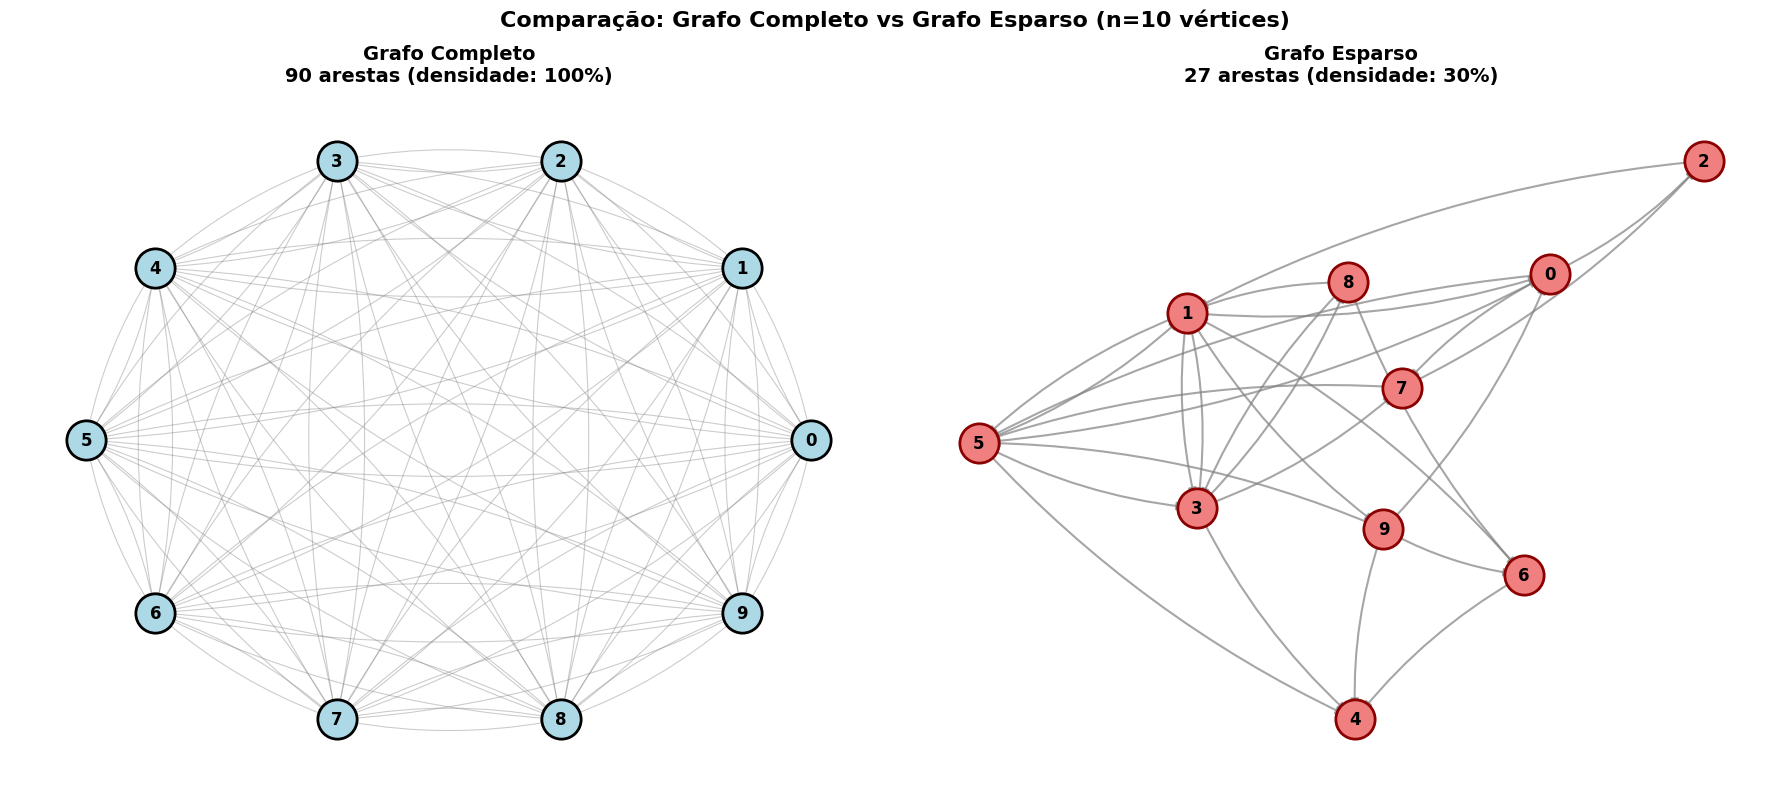

In [121]:
# Criar comparação lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# GRAFO COMPLETO (esquerda)
ax1 = axes[0]
grafo_completo_comp = gerar_grafo_completo(n_exemplo, seed=SEED)
G_completo_comp = nx.DiGraph()
for u, vizinhos in grafo_completo_comp.items():
    for v, peso in vizinhos:
        G_completo_comp.add_edge(u, v, weight=peso)

pos_completo = nx.circular_layout(G_completo_comp)

nx.draw_networkx_nodes(G_completo_comp, pos_completo, node_color='lightblue', 
                      node_size=800, edgecolors='black', linewidths=2, ax=ax1)
nx.draw_networkx_edges(G_completo_comp, pos_completo, edge_color='gray', 
                      arrows=True, arrowsize=12, width=0.8,
                      connectionstyle='arc3,rad=0.1', alpha=0.4, ax=ax1)
nx.draw_networkx_labels(G_completo_comp, pos_completo, font_size=12, font_weight='bold', ax=ax1)

num_arestas_completo = G_completo_comp.number_of_edges()
densidade_completo = nx.density(G_completo_comp)

ax1.set_title(f'Grafo Completo\n{num_arestas_completo} arestas (densidade: {densidade_completo:.0%})', 
             fontsize=14, fontweight='bold', pad=15)
ax1.axis('off')

# GRAFO ESPARSO (direita)
ax2 = axes[1]

pos_esparso = nx.spring_layout(G_esparso, seed=SEED, k=1.5, iterations=50)

nx.draw_networkx_nodes(G_esparso, pos_esparso, node_color='lightcoral', 
                      node_size=800, edgecolors='darkred', linewidths=2, ax=ax2)
nx.draw_networkx_edges(G_esparso, pos_esparso, edge_color='gray', 
                      arrows=True, arrowsize=12, width=1.5,
                      connectionstyle='arc3,rad=0.1', alpha=0.7, ax=ax2)
nx.draw_networkx_labels(G_esparso, pos_esparso, font_size=12, font_weight='bold', ax=ax2)

num_arestas_esparso = G_esparso.number_of_edges()
densidade_esparso = nx.density(G_esparso)

ax2.set_title(f'Grafo Esparso\n{num_arestas_esparso} arestas (densidade: {densidade_esparso:.0%})', 
             fontsize=14, fontweight='bold', pad=15)
ax2.axis('off')

# Título geral
fig.suptitle(f'Comparação: Grafo Completo vs Grafo Esparso (n={n_exemplo} vértices)', 
            fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig('resultados/dijkstra/img/comparacao_completo_vs_esparso.png', dpi=200, bbox_inches='tight')
print('✓ Comparação visual salva: resultados/dijkstra/img/comparacao_completo_vs_esparso.png')

print(f'\n📊 COMPARAÇÃO:')
print(f'{"="*70}')
print(f'  Tipo          │ Vértices │ Arestas │ Densidade │ Redução')
print(f'{"-"*70}')
print(f'  Completo      │    {n_exemplo:2d}    │   {num_arestas_completo:3d}   │  {densidade_completo:6.0%}  │    -')
print(f'  Esparso       │    {n_exemplo:2d}    │   {num_arestas_esparso:3d}   │  {densidade_esparso:6.0%}  │  {(1-densidade_esparso)*100:5.1f}%')
print(f'{"="*70}')
print(f'\n💡 Observação: Grafos esparsos têm MUITO menos arestas que grafos completos,')
print(f'   o que reduz significativamente o número de comparações nos algoritmos.')

plt.show()


### (c) Aplicar algoritmo de Dijkstra

In [122]:
# Aplicar Dijkstra nos grafos de teste
resultados_teste = [dijkstra(g, origem=ORIGEM) for g in grafos_teste]

print(f"✓ Dijkstra executado em {len(resultados_teste)} grafos de teste")
print(f"\nExemplos de comparações:")
for i in range(min(3, len(ns_teste))):
    comp = resultados_teste[i][2]
    print(f"  n={ns_teste[i]}: {comp} comparações")

✓ Dijkstra executado em 997 grafos de teste

Exemplos de comparações:
  n=4: 12 comparações
  n=5: 20 comparações
  n=6: 30 comparações


### (d) Contar número de comparações

In [123]:
# Extrair comparações
comparacoes_teste = [r[2] for r in resultados_teste]

# Salvar resultados de teste
os.makedirs('resultados/dijkstra', exist_ok=True)
with open('resultados/dijkstra/teste_comparacoes.txt', 'w') as f:
    f.write('n\tcomparacoes\n')
    for n, comp in zip(ns_teste, comparacoes_teste):
        f.write(f'{n}\t{comp}\n')

print('✓ Comparações contadas e salvas')
print(f'  Arquivo: resultados/dijkstra/teste_comparacoes.txt')

✓ Comparações contadas e salvas
  Arquivo: resultados/dijkstra/teste_comparacoes.txt


### (e) Plotar gráfico: n vs comparações (Dijkstra)

✓ Gráfico Dijkstra salvo: resultados/dijkstra/img/teste_comparacoes.png


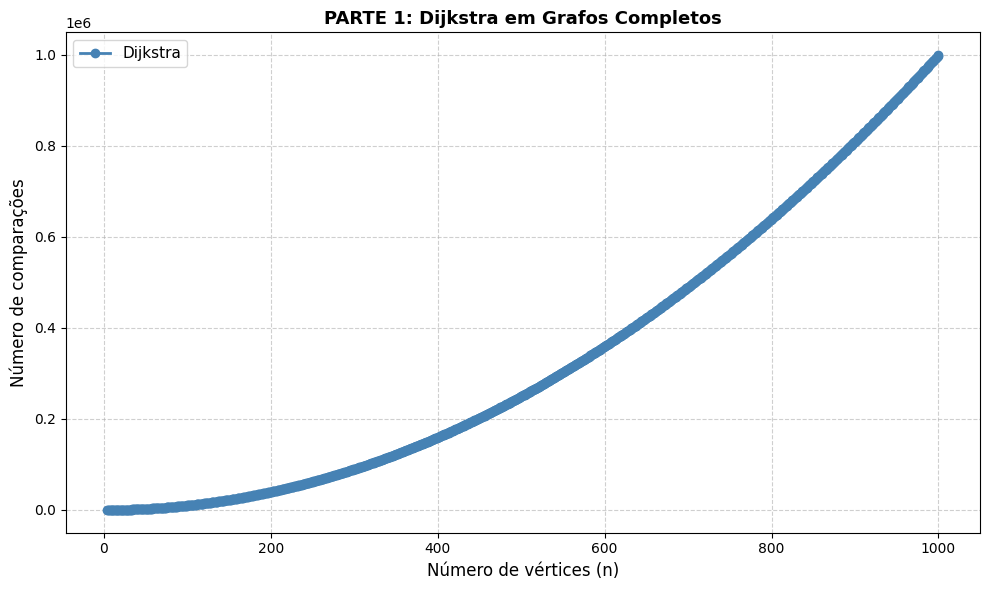

In [124]:
# Gráfico Dijkstra - grafos completos
plt.figure(figsize=(10, 6))
plt.plot(ns_teste, comparacoes_teste, marker='o', linewidth=2, markersize=6, color='steelblue', label='Dijkstra')
plt.xlabel('Número de vértices (n)', fontsize=12)
plt.ylabel('Número de comparações', fontsize=12)
plt.title('PARTE 1: Dijkstra em Grafos Completos', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

os.makedirs('resultados/dijkstra/img', exist_ok=True)
plt.savefig('resultados/dijkstra/img/teste_comparacoes.png', dpi=150)
print('✓ Gráfico Dijkstra salvo: resultados/dijkstra/img/teste_comparacoes.png')
plt.show()

### (f) Aplicar em instâncias grandes (10k e 1M vértices)

**Agora aplicamos o algoritmo testado nas instâncias grandes.**

In [125]:
def carregar_grafo_ewd(caminho: str):
    """Carrega grafo em formato EWD."""
    with open(caminho, 'r', encoding='utf-8') as f:
        V = int(f.readline().strip())
        E = int(f.readline().strip())
        adj = {i: [] for i in range(V)}
        
        for _ in range(E):
            linha = f.readline().strip()
            if not linha:
                break
            u, v, peso = linha.split()[:3]
            adj[int(u)].append((int(v), float(peso)))
    return adj

print('✓ Função de carregamento de grafos grandes criada')

✓ Função de carregamento de grafos grandes criada


In [126]:
# Caminhos das instâncias
caminho_10k = r'D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\10000.txt'
caminho_1m = r'D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\1000000.txt'

print('Caminhos configurados:')
print(f'  10k:  {os.path.exists(caminho_10k) and "✓ Encontrado" or "✗ Não encontrado"}')
print(f'  1M:   {os.path.exists(caminho_1m) and "✓ Encontrado" or "✗ Não encontrado"}')

Caminhos configurados:
  10k:  ✓ Encontrado
  1M:   ✓ Encontrado


In [127]:
# Executar Dijkstra na instância 10k
print('='*70)
print('EXECUTANDO DIJKSTRA - INSTÂNCIA 10.000 VÉRTICES')
print('='*70)

if os.path.exists(caminho_10k):
    print('Carregando grafo...')
    grafo_10k = carregar_grafo_ewd(caminho_10k)
    print(f'✓ Carregado: {len(grafo_10k):,} vértices')
    
    print(f'Executando Dijkstra (origem={ORIGEM})...')
    dist_10k, parent_10k, comp_dijkstra_10k = dijkstra(grafo_10k, origem=ORIGEM)
    
    alcancados_10k = sum(1 for d in dist_10k.values() if d != inf)
    
    print(f'\n📊 RESULTADOS:')
    print(f'   Vértices: {len(dist_10k):,}')
    print(f'   Comparações: {comp_dijkstra_10k:,}')
    print(f'   Alcançados: {alcancados_10k:,}')
    
    # Salvar
    os.makedirs('resultados/dijkstra/instancias', exist_ok=True)
    with open('resultados/dijkstra/instancias/10k_dijkstra.txt', 'w') as f:
        f.write('DIJKSTRA - Instância 10.000 vértices\n')
        f.write('='*60 + '\n')
        f.write(f'Origem: {ORIGEM}\n')
        f.write(f'Vértices: {len(dist_10k):,}\n')
        f.write(f'Comparações: {comp_dijkstra_10k:,}\n')
        f.write(f'Alcançados: {alcancados_10k:,}\n')
    print('💾 Salvo: resultados/dijkstra/instancias/10k_dijkstra.txt')
else:
    print('⚠️ Arquivo não encontrado!')
    comp_dijkstra_10k = None

EXECUTANDO DIJKSTRA - INSTÂNCIA 10.000 VÉRTICES
Carregando grafo...
✓ Carregado: 10,000 vértices
Executando Dijkstra (origem=0)...

📊 RESULTADOS:
   Vértices: 10,000
   Comparações: 123,462
   Alcançados: 10,000
💾 Salvo: resultados/dijkstra/instancias/10k_dijkstra.txt


In [128]:
# Executar Dijkstra na instância 1M (DESCOMENTE PARA EXECUTAR)

print('='*70)
print('EXECUTANDO DIJKSTRA - INSTÂNCIA 1.000.000 VÉRTICES')
print('='*70)

if os.path.exists(caminho_1m):
    print('Carregando grafo...')
    grafo_1m = carregar_grafo_ewd(caminho_1m)
    print(f'✓ Carregado: {len(grafo_1m):,} vértices')
    
    print(f'Executando Dijkstra (origem={ORIGEM})...')
    dist_1m, parent_1m, comp_dijkstra_1m = dijkstra(grafo_1m, origem=ORIGEM)
    
    alcancados_1m = sum(1 for d in dist_1m.values() if d != inf)
    
    print(f'\n📊 RESULTADOS:')
    print(f'   Vértices: {len(dist_1m):,}')
    print(f'   Comparações: {comp_dijkstra_1m:,}')
    print(f'   Alcançados: {alcancados_1m:,}')
    
    # Salvar
    with open('resultados/dijkstra/instancias/1m_dijkstra.txt', 'w') as f:
        f.write('DIJKSTRA - Instância 1.000.000 vértices\n')
        f.write('='*60 + '\n')
        f.write(f'Origem: {ORIGEM}\n')
        f.write(f'Vértices: {len(dist_1m):,}\n')
        f.write(f'Comparações: {comp_dijkstra_1m:,}\n')
        f.write(f'Alcançados: {alcancados_1m:,}\n')
    print('💾 Salvo: resultados/dijkstra/instancias/1m_dijkstra.txt')
else:
    print('⚠️ Arquivo não encontrado!')
    comp_dijkstra_1m = None

print('ℹ️  Instância 1M comentada. Descomente o bloco acima para executar.')

EXECUTANDO DIJKSTRA - INSTÂNCIA 1.000.000 VÉRTICES
Carregando grafo...
✓ Carregado: 1,000,000 vértices
Executando Dijkstra (origem=0)...

📊 RESULTADOS:
   Vértices: 1,000,000
   Comparações: 15,172,126
   Alcançados: 1,000,000
💾 Salvo: resultados/dijkstra/instancias/1m_dijkstra.txt
ℹ️  Instância 1M comentada. Descomente o bloco acima para executar.


---
# PARTE 2: HEURÍSTICA GULOSA
---

## I. Implementação da Heurística Gulosa

In [129]:
def heuristica_gulosa(adj: Dict[int, List[Tuple[int, float]]], origem: int = 0):
    """
    Heurística gulosa (vizinho mais próximo) para GRAFO DIRIGIDO com pesos não negativos.
    ATENÇÃO: NÃO garante solução ótima!
    
    Percorre apenas arestas de saída u->v (direcionais) a partir do vértice atual.
    
    Retorna: (dist, parent, comparacoes)
    """
    if origem not in adj:
        raise ValueError('Origem inválida')
    
    dist = {u: inf for u in adj}
    parent = {u: None for u in adj}
    dist[origem] = 0.0
    visited = {origem}
    fila = deque([origem])
    comparacoes = 0
    
    while fila:
        u = fila.popleft()
        melhor_v = None
        melhor_custo = inf
        
        # Para grafos DIRIGIDOS: considera somente arestas u->v
        for v, peso in adj[u]:
            comparacoes += 1
            if v in visited:
                continue
            custo = dist[u] + peso
            if custo < dist[v] and custo < melhor_custo:
                melhor_custo = custo
                melhor_v = v
        
        if melhor_v is not None:
            dist[melhor_v] = melhor_custo
            parent[melhor_v] = u
            visited.add(melhor_v)
            fila.append(melhor_v)
    
    return dist, parent, comparacoes

## II. Teste da Heurística

### (a) e (b) Reutilizar grafos completos de teste

Usamos os mesmos grafos gerados para testar Dijkstra.

In [130]:
print(f"✓ Reutilizando {len(grafos_teste)} grafos de teste")
print(f"  Tamanhos: n={N_MIN} até n={N_MAX}")

✓ Reutilizando 997 grafos de teste
  Tamanhos: n=4 até n=1000


### (c) Aplicar heurística gulosa

In [131]:
# Aplicar heurística gulosa nos grafos de teste
resultados_gulosa_teste = [heuristica_gulosa(g, origem=ORIGEM) for g in grafos_teste]

print(f"✓ Heurística gulosa executada em {len(resultados_gulosa_teste)} grafos")
print(f"\nExemplos de comparações:")
for i in range(min(3, len(ns_teste))):
    comp = resultados_gulosa_teste[i][2]
    print(f"  n={ns_teste[i]}: {comp} comparações")

✓ Heurística gulosa executada em 997 grafos

Exemplos de comparações:
  n=4: 12 comparações
  n=5: 20 comparações
  n=6: 30 comparações


### (d) Contar número de comparações

In [132]:
# Extrair comparações
comparacoes_gulosa_teste = [r[2] for r in resultados_gulosa_teste]

# Salvar
os.makedirs('resultados/gulosa', exist_ok=True)
with open('resultados/gulosa/teste_comparacoes.txt', 'w') as f:
    f.write('n\tcomparacoes\n')
    for n, comp in zip(ns_teste, comparacoes_gulosa_teste):
        f.write(f'{n}\t{comp}\n')

print('✓ Comparações contadas e salvas')
print(f'  Arquivo: resultados/gulosa/teste_comparacoes.txt')

✓ Comparações contadas e salvas
  Arquivo: resultados/gulosa/teste_comparacoes.txt


### (e) Plotar gráfico: n vs comparações

✓ Gráfico de teste salvo: resultados/gulosa/img/teste_comparacoes.png


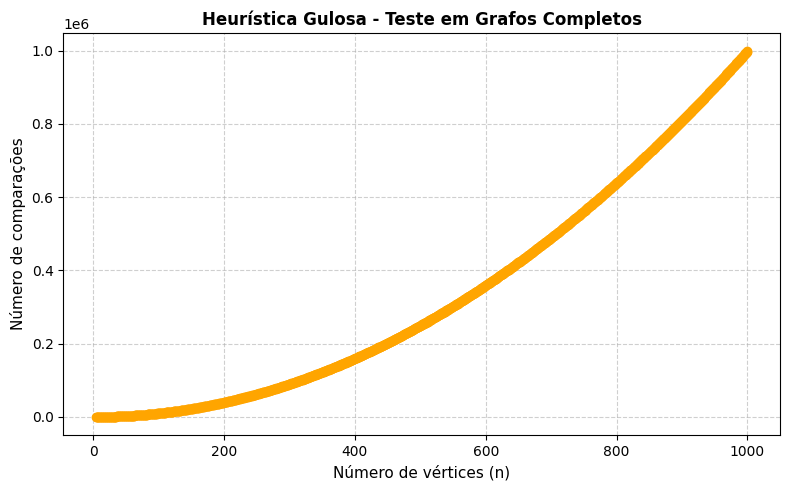

In [133]:
# Gráfico de teste
plt.figure(figsize=(8, 5))
plt.plot(ns_teste, comparacoes_gulosa_teste, marker='o', color='orange', linewidth=2, markersize=6)
plt.xlabel('Número de vértices (n)', fontsize=11)
plt.ylabel('Número de comparações', fontsize=11)
plt.title('Heurística Gulosa - Teste em Grafos Completos', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

os.makedirs('resultados/gulosa/img', exist_ok=True)
plt.savefig('resultados/gulosa/img/teste_comparacoes.png', dpi=150)
print('✓ Gráfico de teste salvo: resultados/gulosa/img/teste_comparacoes.png')
plt.show()

### (f) Aplicar em instâncias grandes (10k e 1M vértices)

**Agora aplicamos a heurística testada nas instâncias grandes.**

In [134]:
# Executar Gulosa na instância 10k
print('='*70)
print('EXECUTANDO GULOSA - INSTÂNCIA 10.000 VÉRTICES')
print('='*70)

if os.path.exists(caminho_10k):
    print('Carregando grafo...')
    if 'grafo_10k' not in locals():
        grafo_10k = carregar_grafo_ewd(caminho_10k)
    print(f'✓ Carregado: {len(grafo_10k):,} vértices')
    
    print(f'Executando Heurística Gulosa (origem={ORIGEM})...')
    dist_g10k, parent_g10k, comp_gulosa_10k = heuristica_gulosa(grafo_10k, origem=ORIGEM)
    
    alcancados_g10k = sum(1 for d in dist_g10k.values() if d != inf)
    
    print(f'\n📊 RESULTADOS:')
    print(f'   Vértices: {len(dist_g10k):,}')
    print(f'   Comparações: {comp_gulosa_10k:,}')
    print(f'   Alcançados: {alcancados_g10k:,}')
    
    # Salvar
    os.makedirs('resultados/gulosa/instancias', exist_ok=True)
    with open('resultados/gulosa/instancias/10k_gulosa.txt', 'w') as f:
        f.write('HEURÍSTICA GULOSA - Instância 10.000 vértices\n')
        f.write('='*60 + '\n')
        f.write(f'Origem: {ORIGEM}\n')
        f.write(f'Vértices: {len(dist_g10k):,}\n')
        f.write(f'Comparações: {comp_gulosa_10k:,}\n')
        f.write(f'Alcançados: {alcancados_g10k:,}\n')
    print('💾 Salvo: resultados/gulosa/instancias/10k_gulosa.txt')
else:
    print('⚠️ Arquivo não encontrado!')
    comp_gulosa_10k = None

EXECUTANDO GULOSA - INSTÂNCIA 10.000 VÉRTICES
Carregando grafo...
✓ Carregado: 10,000 vértices
Executando Heurística Gulosa (origem=0)...

📊 RESULTADOS:
   Vértices: 10,000
   Comparações: 424
   Alcançados: 28
💾 Salvo: resultados/gulosa/instancias/10k_gulosa.txt


In [135]:
# Executar Gulosa na instância 1M (DESCOMENTE PARA EXECUTAR)

print('='*70)
print('EXECUTANDO GULOSA - INSTÂNCIA 1.000.000 VÉRTICES')
print('='*70)

if os.path.exists(caminho_1m):
    print('Carregando grafo...')
    if 'grafo_1m' not in locals():
        grafo_1m = carregar_grafo_ewd(caminho_1m)
    print(f'✓ Carregado: {len(grafo_1m):,} vértices')
    
    print(f'Executando Heurística Gulosa (origem={ORIGEM})...')
    dist_g1m, parent_g1m, comp_gulosa_1m = heuristica_gulosa(grafo_1m, origem=ORIGEM)
    
    alcancados_g1m = sum(1 for d in dist_g1m.values() if d != inf)
    
    print(f'\n📊 RESULTADOS:')
    print(f'   Vértices: {len(dist_g1m):,}')
    print(f'   Comparações: {comp_gulosa_1m:,}')
    print(f'   Alcançados: {alcancados_g1m:,}')
    
    # Salvar
    with open('resultados/gulosa/instancias/1m_gulosa.txt', 'w') as f:
        f.write('HEURÍSTICA GULOSA - Instância 1.000.000 vértices\n')
        f.write('='*60 + '\n')
        f.write(f'Origem: {ORIGEM}\n')
        f.write(f'Vértices: {len(dist_g1m):,}\n')
        f.write(f'Comparações: {comp_gulosa_1m:,}\n')
        f.write(f'Alcançados: {alcancados_g1m:,}\n')
    print('💾 Salvo: resultados/gulosa/instancias/1m_gulosa.txt')
else:
    print('⚠️ Arquivo não encontrado!')
    comp_gulosa_1m = None

print('ℹ️  Instância 1M comentada. Descomente o bloco acima para executar.')

EXECUTANDO GULOSA - INSTÂNCIA 1.000.000 VÉRTICES
Carregando grafo...
✓ Carregado: 1,000,000 vértices
Executando Heurística Gulosa (origem=0)...

📊 RESULTADOS:
   Vértices: 1,000,000
   Comparações: 1,847
   Alcançados: 120
💾 Salvo: resultados/gulosa/instancias/1m_gulosa.txt
ℹ️  Instância 1M comentada. Descomente o bloco acima para executar.


---
# COMPARAÇÃO FINAL
---

## Comparação em Grafos de Teste

✓ Gráfico salvo: resultados/comparacao/teste_dijkstra_vs_gulosa.png


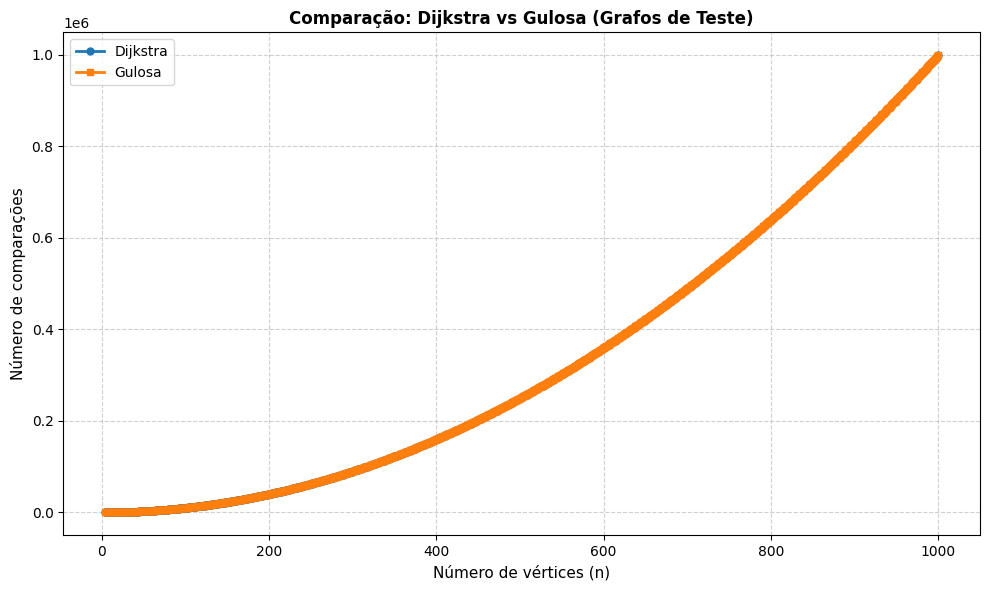

In [136]:
# Gráfico comparativo - grafos de teste
plt.figure(figsize=(10, 6))
plt.plot(ns_teste, comparacoes_teste, marker='o', label='Dijkstra', linewidth=2, markersize=5)
plt.plot(ns_teste, comparacoes_gulosa_teste, marker='s', label='Gulosa', linewidth=2, markersize=5)
plt.xlabel('Número de vértices (n)', fontsize=11)
plt.ylabel('Número de comparações', fontsize=11)
plt.title('Comparação: Dijkstra vs Gulosa (Grafos de Teste)', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

os.makedirs('resultados/comparacao', exist_ok=True)
plt.savefig('resultados/comparacao/teste_dijkstra_vs_gulosa.png', dpi=150)
print('✓ Gráfico salvo: resultados/comparacao/teste_dijkstra_vs_gulosa.png')
plt.show()

## Comparação em Instâncias Grandes

In [137]:
# Comparação numérica das instâncias grandes
print('\n' + '='*70)
print('📊 COMPARAÇÃO FINAL - INSTÂNCIAS GRANDES')
print('='*70)

if 'comp_dijkstra_10k' in locals() and 'comp_gulosa_10k' in locals():
    if comp_dijkstra_10k is not None and comp_gulosa_10k is not None:
        print('\n🔹 INSTÂNCIA 10.000 VÉRTICES')
        print('-' * 70)
        print(f'  {"Algoritmo":<20} {"Comparações":>15}   {"Alcançados":>12}')
        print('-' * 70)
        print(f'  {"Dijkstra":<20} {comp_dijkstra_10k:>15,}   {alcancados_10k:>12,}')
        print(f'  {"Heurística Gulosa":<20} {comp_gulosa_10k:>15,}   {alcancados_g10k:>12,}')
        print('-' * 70)
        
        reducao = (1 - comp_gulosa_10k / comp_dijkstra_10k) * 100
        dif_alcancados = alcancados_10k - alcancados_g10k
        
        print(f'\n  📉 Redução de comparações: {reducao:>6.2f}%')
        if comp_gulosa_10k < comp_dijkstra_10k:
            print(f'  ✓ Gulosa: {comp_dijkstra_10k - comp_gulosa_10k:,} comparações a MENOS')
        else:
            print(f'  ⚠ Gulosa: {comp_gulosa_10k - comp_dijkstra_10k:,} comparações a MAIS')
        
        print(f'\n  🎯 Diferença de alcance: {abs(dif_alcancados):,} vértices')
        if dif_alcancados == 0:
            print(f'  ✓ Ambos alcançaram o mesmo número de vértices')
        elif dif_alcancados > 0:
            print(f'  ⚠ Dijkstra alcançou {dif_alcancados:,} vértices a MAIS')
        else:
            print(f'  ⚠ Gulosa alcançou {abs(dif_alcancados):,} vértices a MAIS')

# Descomente após executar 1M:

if 'comp_dijkstra_1m' in locals() and 'comp_gulosa_1m' in locals():
    if comp_dijkstra_1m is not None and comp_gulosa_1m is not None:
        print('\n🔹 INSTÂNCIA 1.000.000 VÉRTICES')
        print('-' * 70)
        print(f'  {"Algoritmo":<20} {"Comparações":>15}   {"Alcançados":>12}')
        print('-' * 70)
        print(f'  {"Dijkstra":<20} {comp_dijkstra_1m:>15,}   {alcancados_1m:>12,}')
        print(f'  {"Heurística Gulosa":<20} {comp_gulosa_1m:>15,}   {alcancados_g1m:>12,}')
        print('-' * 70)
        
        reducao_1m = (1 - comp_gulosa_1m / comp_dijkstra_1m) * 100
        dif_alcancados_1m = alcancados_1m - alcancados_g1m
        
        print(f'\n  📉 Redução de comparações: {reducao_1m:>6.2f}%')
        if comp_gulosa_1m < comp_dijkstra_1m:
            print(f'  ✓ Gulosa: {comp_dijkstra_1m - comp_gulosa_1m:,} comparações a MENOS')
        else:
            print(f'  ⚠ Gulosa: {comp_gulosa_1m - comp_dijkstra_1m:,} comparações a MAIS')
        
        print(f'\n  🎯 Diferença de alcance: {abs(dif_alcancados_1m):,} vértices')
        if dif_alcancados_1m == 0:
            print(f'  ✓ Ambos alcançaram o mesmo número de vértices')
        elif dif_alcancados_1m > 0:
            print(f'  ⚠ Dijkstra alcançou {dif_alcancados_1m:,} vértices a MAIS')
        else:
            print(f'  ⚠ Gulosa alcançou {abs(dif_alcancados_1m):,} vértices a MAIS')


print('\n' + '='*70)



📊 COMPARAÇÃO FINAL - INSTÂNCIAS GRANDES

🔹 INSTÂNCIA 10.000 VÉRTICES
----------------------------------------------------------------------
  Algoritmo                Comparações     Alcançados
----------------------------------------------------------------------
  Dijkstra                     123,462         10,000
  Heurística Gulosa                424             28
----------------------------------------------------------------------

  📉 Redução de comparações:  99.66%
  ✓ Gulosa: 123,038 comparações a MENOS

  🎯 Diferença de alcance: 9,972 vértices
  ⚠ Dijkstra alcançou 9,972 vértices a MAIS

🔹 INSTÂNCIA 1.000.000 VÉRTICES
----------------------------------------------------------------------
  Algoritmo                Comparações     Alcançados
----------------------------------------------------------------------
  Dijkstra                  15,172,126      1,000,000
  Heurística Gulosa              1,847            120
--------------------------------------------------------

✓ Gráfico salvo: resultados/comparacao/instancias_grandes.png


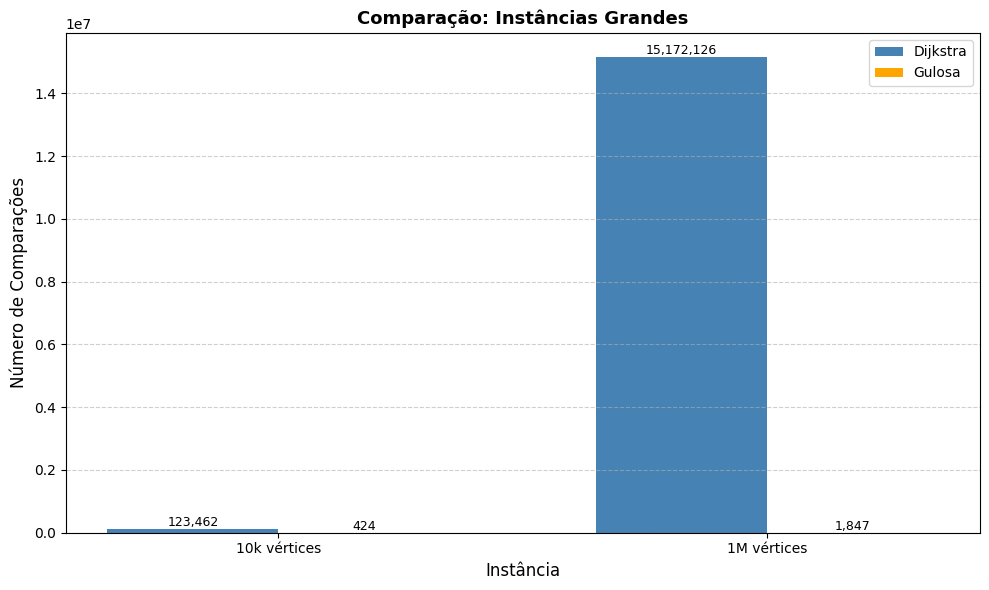

In [138]:
# Gráfico de barras - instâncias grandes
if 'comp_dijkstra_10k' in locals() and 'comp_gulosa_10k' in locals():
    if comp_dijkstra_10k is not None and comp_gulosa_10k is not None:
        instancias = ['10k vértices']
        dijkstra_vals = [comp_dijkstra_10k]
        gulosa_vals = [comp_gulosa_10k]
        
        # Adicionar 1M se executado
        if 'comp_dijkstra_1m' in locals() and comp_dijkstra_1m is not None:
            instancias.append('1M vértices')
            dijkstra_vals.append(comp_dijkstra_1m)
            gulosa_vals.append(comp_gulosa_1m)
        
        x = np.arange(len(instancias))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(10, 6))
        bars1 = ax.bar(x - width/2, dijkstra_vals, width, label='Dijkstra', color='steelblue')
        bars2 = ax.bar(x + width/2, gulosa_vals, width, label='Gulosa', color='orange')
        
        ax.set_xlabel('Instância', fontsize=12)
        ax.set_ylabel('Número de Comparações', fontsize=12)
        ax.set_title('Comparação: Instâncias Grandes', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(instancias)
        ax.legend()
        ax.grid(True, axis='y', linestyle='--', alpha=0.6)
        
        # Valores nas barras
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height):,}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.savefig('resultados/comparacao/instancias_grandes.png', dpi=150)
        print('✓ Gráfico salvo: resultados/comparacao/instancias_grandes.png')
        plt.show()

In [139]:
# Salvar relatório completo
with open('resultados/comparacao/relatorio_completo.txt', 'w', encoding='utf-8') as f:
    f.write('RELATÓRIO COMPLETO: DIJKSTRA vs HEURÍSTICA GULOSA\n')
    f.write('='*70 + '\n\n')
    
    f.write('GRAFOS DE TESTE\n')
    f.write('-'*70 + '\n')
    f.write(f'Tamanhos testados: n={N_MIN} até n={N_MAX}\n')
    f.write(f'Dijkstra - Comparações: min={min(comparacoes_teste):,}, max={max(comparacoes_teste):,}\n')
    f.write(f'Gulosa - Comparações: min={min(comparacoes_gulosa_teste):,}, max={max(comparacoes_gulosa_teste):,}\n\n')
    
    if 'comp_dijkstra_10k' in locals() and comp_dijkstra_10k is not None:
        f.write('INSTÂNCIA 10.000 VÉRTICES\n')
        f.write('-'*70 + '\n')
        f.write(f'Dijkstra: {comp_dijkstra_10k:,} comparações\n')
        if 'comp_gulosa_10k' in locals() and comp_gulosa_10k is not None:
            f.write(f'Gulosa: {comp_gulosa_10k:,} comparações\n')
            f.write(f'Redução: {(1 - comp_gulosa_10k/comp_dijkstra_10k)*100:.2f}%\n\n')

print('✓ Relatório completo salvo: resultados/comparacao/relatorio_completo.txt')

✓ Relatório completo salvo: resultados/comparacao/relatorio_completo.txt
